In [23]:
# run if working in colab
#!git clone https://github.com/sanjanachecker/CSC522_WatermarkAttacker.git

Cloning into 'CSC522_WatermarkAttacker'...
remote: Enumerating objects: 521, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (67/67), done.
^C


In [1]:
import os
%cd CSC522_WatermarkAttacker/
!pwd

/content/CSC522_WatermarkAttacker
/content/CSC522_WatermarkAttacker


# Lipschitz Constant Measurement - Testing Paper's Assumption

**Goal**: Prove L_x,w can be >> 1, breaking the paper's CWF guarantee (CONTRIBUTIONS.md)

**Method**:
1. Baseline: Measure L_x,w for standard watermarks (expect ≈1-5)
2. Adversarial: Use PGD to maximize ||φ(x+δ) - φ(x)||² subject to ||δ|| ≤ Δ
3. Compare: Show L_adv >> L_baseline, proving assumption violation

In [2]:
!pip install --upgrade pip setuptools

In [3]:
!pip install -r requirements.txt

  Using cached invisible_watermark-0.2.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached bm3d-4.0.3-py3-none-any.whl.metadata (2.3 kB)
  Using cached compressai-1.2.8-cp312-cp312-manylinux_2_34_x86_64.whl.metadata (9.0 kB)
  Using cached torch_fidelity-0.4.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached onnxruntime-1.24.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.1 kB)
  Using cached bm4d-4.2.5-py3-none-any.whl.metadata (3.1 kB)
INFO: pip is looking at multiple versions of compressai to determine which version is compatible with other requirements. This could take a while.
  Using cached compressai-1.2.7-cp312-cp312-manylinux_2_34_x86_64.whl.metadata (9.0 kB)
  Using cached compressai-1.2.6.tar.gz (163 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import torch
import torch.nn.functional as F
import numpy as np
import os
import cv2
import shutil
from datetime import datetime
from PIL import Image
from tqdm import tqdm
from regen_pipe import ReSDPipeline
from watermarker import InvisibleWatermarker
from wmattacker import VAEWMAttacker
from utils import eval_psnr_ssim_msssim
import matplotlib.pyplot as plt


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/compressai/models/video/google.py:353: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @amp.autocast(enabled=False)


In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

image_dir = 'lipschitz_test_imgs/'
base_output_dir = '/content/drive/MyDrive/lipschitz_results/'
run_tag = datetime.now().strftime('run_%Y%m%d_%H%M%S')
output_dir = os.path.join(base_output_dir, run_tag)
os.makedirs(output_dir, exist_ok=True)
print(f'Output directory: {output_dir}')

Output directory: /content/drive/MyDrive/lipschitz_results/run_20260308_203954


## Load Stable Diffusion VAE (φ function from paper's equation 2)

In [11]:
# Load SD VAE encoder as φ (embedding function in paper's framework)
pipe = ReSDPipeline.from_pretrained(
    "Manojb/stable-diffusion-2-1-base",
    torch_dtype=torch.float32 if device == "cpu" else torch.float16
)
pipe.to(device)
vae = pipe.vae  # φ in equation (2): z_t = √α(t)·E(x_w) + N(0,(1-α(t))I_d)
print('Model loaded')

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--Manojb--stable-diffusion-2-1-base/snapshots/0094d483a120f3f33dafbd187ea4aa60d10de75c/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded


## Helper Functions for Lipschitz Measurement (CONTRIBUTIONS.md Step 3)

In [12]:
def load_image_tensor(path, device):
    img = Image.open(path).convert('RGB').resize((512, 512))
    img = np.asarray(img) / 255.0
    img = (img - 0.5) * 2
    return torch.tensor(img, dtype=vae.dtype, device=device).permute(2, 0, 1).unsqueeze(0)

def get_latent(img_tensor, vae):
    """Compute φ(x) using VAE encoder"""
    with torch.no_grad():
        return vae.encode(img_tensor).latent_dist.mean

def compute_lipschitz(x, x_w, vae):
    """Calculate L_x,w = ||φ(x_w) - φ(x)|| / ||x_w - x|| (CONTRIBUTIONS.md)"""
    pixel_dist = torch.norm(x_w - x).item()  # ||x_w - x|| in pixel space
    latent_x = get_latent(x, vae)
    latent_xw = get_latent(x_w, vae)
    latent_dist = torch.norm(latent_xw - latent_x).item()  # ||φ(x_w) - φ(x)|| in latent space
    return latent_dist / pixel_dist if pixel_dist > 0 else 0, pixel_dist, latent_dist

## Step 1: Baseline - Standard Watermarks (CONTRIBUTIONS.md Step 2)

**Expected**: L_x,w ≈ 1-5 (embedding doesn't amplify watermark)

In [16]:
# Standard watermarking methods for baseline comparison
wmarkers = {
    'DwtDct': InvisibleWatermarker('test', 'dwtDct'),
    'DwtDctSvd': InvisibleWatermarker('test', 'dwtDctSvd'),
    'RivaGAN': InvisibleWatermarker('test', 'rivaGan'),
}

In [17]:
import glob
image_paths = sorted(glob.glob(os.path.join(image_dir, '*.png')))[:20]
print(f'Found {len(image_paths)} images')

Found 20 images


In [18]:
# Measure baseline L_x,w for standard watermarks
baseline_results = {}

for wm_name, wmarker in wmarkers.items():
    print(f'\nProcessing {wm_name}...')
    lipschitz_constants = []
    pixel_dists = []
    latent_dists = []
    psnr_vals, ssim_vals, msssim_vals = [], [], []

    wm_save_dir = os.path.join(output_dir, 'standard_watermarks', wm_name)
    os.makedirs(wm_save_dir, exist_ok=True)

    for img_path in tqdm(image_paths):
        wm_path = os.path.join(wm_save_dir, os.path.basename(img_path))
        wmarker.encode(img_path, wm_path)

        x = load_image_tensor(img_path, device)
        x_w = load_image_tensor(wm_path, device)

        L, pd, ld = compute_lipschitz(x, x_w, vae)
        lipschitz_constants.append(L)
        pixel_dists.append(pd)
        latent_dists.append(ld)
        psnr, ssim_val, msssim_val = eval_psnr_ssim_msssim(img_path, wm_path)
        psnr_vals.append(psnr)
        ssim_vals.append(ssim_val)
        msssim_vals.append(msssim_val)

    baseline_results[wm_name] = {
        'L_mean': np.mean(lipschitz_constants),
        'L_std': np.std(lipschitz_constants),
        'pixel_dist_mean': np.mean(pixel_dists),
        'latent_dist_mean': np.mean(latent_dists),
        'psnr_mean': np.mean(psnr_vals),
        'ssim_mean': np.mean(ssim_vals),
        'msssim_mean': np.mean(msssim_vals)
    }
    print(f'{wm_name}: L = {baseline_results[wm_name]["L_mean"]:.4f} ± {baseline_results[wm_name]["L_std"]:.4f}, '
      f'PSNR = {baseline_results[wm_name]["psnr_mean"]:.2f}, SSIM = {baseline_results[wm_name]["ssim_mean"]:.4f}, MSSSIM = {baseline_results[wm_name]["msssim_mean"]:.4f}')


Processing DwtDct...


100%|██████████| 20/20 [00:13<00:00,  1.50it/s]


DwtDct: L = 2.1420 ± 2.2327, PSNR = 38.53, SSIM = 0.9864, MSSSIM = 0.9962

Processing DwtDctSvd...


100%|██████████| 20/20 [00:14<00:00,  1.42it/s]


DwtDctSvd: L = 3.0216 ± 2.3007, PSNR = 38.70, SSIM = 0.9904, MSSSIM = 0.9942

Processing RivaGAN...


100%|██████████| 20/20 [01:07<00:00,  3.40s/it]

RivaGAN: L = 4.1134 ± 2.8886, PSNR = 40.64, SSIM = 0.9910, MSSSIM = 0.9945


## Step 2: Adversarial Watermark via PGD (CONTRIBUTIONS.md Step 3)

**Objective**: Maximize J = ||φ(x+δ) - φ(x)||² subject to ||δ|| ≤ ε

**Rationale**: Paper admits "if watermark is carefully designed...aligned with adversarial perturbation, L_x,w >> 1" (CONTEXT.md)

In [19]:
def tensor_to_bgr_uint8(x_tensor):
    x = x_tensor.detach().squeeze(0).permute(1, 2, 0).cpu().numpy()
    x = ((x + 1.0) / 2.0)
    x = np.clip(x * 255.0, 0, 255).astype(np.uint8)
    return cv2.cvtColor(x, cv2.COLOR_RGB2BGR)

def save_tensor_image(x_tensor, out_path):
    cv2.imwrite(out_path, tensor_to_bgr_uint8(x_tensor))

def project_l2_ball(x_candidate, x_center, epsilon):
    # Use Linf-style projection (per-pixel bound) for practical watermark strength calibration.
    delta = (x_candidate - x_center).clamp(-epsilon, epsilon)
    return (x_center + delta).clamp(-1, 1)

def text_to_bits(msg_text, k=32):
    raw = msg_text.encode('utf-8')
    bits = []
    for b in raw:
        bits.extend([(b >> i) & 1 for i in range(7, -1, -1)])
    bits = bits[:k]
    if len(bits) < k:
        bits.extend([0] * (k - len(bits)))
    return bits

def build_pair_carriers(num_bits, channels, height, width, key=1234, device='cpu', dtype=torch.float32, grid=64):
    # Two carriers per bit; decode by differential correlation to cancel host bias.
    g = torch.Generator(device=device).manual_seed(key)
    c0_list, c1_list = [], []
    for _ in range(num_bits):
        def sample_carrier():
            base = torch.randint(0, 2, (1, grid, grid), generator=g, device=device).to(dtype)
            base = base * 2 - 1
            c = F.interpolate(base.unsqueeze(0), size=(height, width), mode='bilinear', align_corners=False).squeeze(0)
            c = c.repeat(channels, 1, 1)
            return c / (c.std() + 1e-6)
        c0 = sample_carrier()
        c1 = sample_carrier()
        c0_list.append(c0)
        c1_list.append(c1)
    return torch.stack(c0_list, dim=0), torch.stack(c1_list, dim=0)

def lowpass_band(x):
    return F.avg_pool2d(x, kernel_size=5, stride=1, padding=2)

def pair_logits(x, carriers0, carriers1):
    band = lowpass_band(x)
    corr0 = torch.einsum('bchw,nchw->bn', band, carriers0)
    corr1 = torch.einsum('bchw,nchw->bn', band, carriers1)
    return corr1 - corr0

def decode_pair_bits(x, carriers0, carriers1):
    logits = pair_logits(x, carriers0, carriers1).squeeze(0)
    return (logits > 0).long().detach().cpu().tolist(), logits.detach().cpu().tolist()

def random_augment_for_robustness(x):
    x_aug = x
    if torch.rand(1).item() < 0.6:
        x_aug = F.avg_pool2d(x_aug, kernel_size=3, stride=1, padding=1)
    if torch.rand(1).item() < 0.5:
        noise = 0.006 * torch.randn_like(x_aug)
        x_aug = (x_aug + noise).clamp(-1, 1)
    return x_aug

def build_pair_template(carriers0, carriers1, target_bits):
    # bit=1 uses c1, bit=0 uses c0; template is selected carrier sum.
    b = target_bits.to(carriers0.dtype).view(-1, 1, 1, 1)
    selected = (1.0 - b) * carriers0 + b * carriers1
    template = selected.sum(dim=0, keepdim=True)
    # Max-abs normalization gives controllable per-pixel embedding amplitude.
    return template / (template.abs().max() + 1e-8)

def pair_seed_embed(x_clean, carriers0, carriers1, target_bits, epsilon=14/255):
    template = build_pair_template(carriers0, carriers1, target_bits)
    x_seed = x_clean.to(template.dtype) + epsilon * template
    return project_l2_ball(x_seed, x_clean, epsilon)

def pair_margin_loss(x, carriers0, carriers1, target_bits, target_margin=0.050, eot_samples=2):
    # margin on differential logits: positive for bit=1, negative for bit=0
    y = (target_bits.to(carriers0.dtype) * 2 - 1).view(1, -1)
    loss = 0.0
    for _ in range(eot_samples):
        x_aug = random_augment_for_robustness(x)
        logits = pair_logits(x_aug, carriers0, carriers1)
        signed = y * logits
        loss = loss + F.relu(target_margin - signed).mean()
    return loss / eot_samples

def pgd_latent_boost_constrained(x_start, x_clean, vae, carriers0, carriers1, target_bits, epsilon_total=16/255, alpha=1/255, steps=40, lambda_wm=180.0):
    with torch.no_grad():
        latent_clean = vae.encode(x_clean).latent_dist.mean

    x_adv = project_l2_ball(x_start, x_clean, epsilon_total).detach().to(dtype=vae.dtype)
    for _ in range(steps):
        x_var = x_adv.detach().to(dtype=vae.dtype).requires_grad_(True)
        latent_adv = vae.encode(x_var).latent_dist.mean
        latent_term = -torch.norm(latent_adv - latent_clean) ** 2
        wm_term = pair_margin_loss(x_var, carriers0, carriers1, target_bits, target_margin=0.050, eot_samples=2)
        loss = latent_term + lambda_wm * wm_term
        loss.backward()
        with torch.no_grad():
            proposal = x_var - alpha * x_var.grad.sign()
            x_adv = project_l2_ball(proposal, x_clean, epsilon_total)
    return x_adv.detach()


def pgd_latent_only(x_clean, vae, epsilon_total=16/255, alpha=1/255, steps=45):
    with torch.no_grad():
        latent_clean = vae.encode(x_clean).latent_dist.mean
    x_adv = x_clean.clone().detach().to(dtype=vae.dtype)
    for _ in range(steps):
        x_var = x_adv.detach().to(dtype=vae.dtype).requires_grad_(True)
        latent_adv = vae.encode(x_var).latent_dist.mean
        loss = -torch.norm(latent_adv - latent_clean) ** 2
        loss.backward()
        with torch.no_grad():
            proposal = x_var - alpha * x_var.grad.sign()
            x_adv = project_l2_ball(proposal, x_clean, epsilon_total)
    return x_adv.detach()


## Step 3: Detection Function

**Verify watermark message is preserved using bit accuracy**

In [20]:
from utils import bytearray_to_bits
from scipy.stats import binomtest

def detect_watermark(img_path, wmarker, threshold=23, k=32):
    try:
        wm_decoded = wmarker.decode(img_path)
        bits_decoded = bytearray_to_bits(wm_decoded)[:k]
        bits_original = bytearray_to_bits(wmarker.wm_text.encode('utf-8'))[:k]
        matches = sum(b1 == b2 for b1, b2 in zip(bits_decoded, bits_original))
        bit_acc = matches / k
        p_val = binomtest(matches, k, 0.5, alternative='greater').pvalue
        detected = matches >= threshold
        return detected, bit_acc, p_val
    except Exception:
        return False, 0.0, 1.0

def detect_pair_watermark(x_tensor, carriers0, carriers1, target_bits, threshold=23):
    pred_bits, logits = decode_pair_bits(x_tensor, carriers0, carriers1)
    target = target_bits.detach().cpu().tolist()
    k = len(target)
    matches = sum(int(a == b) for a, b in zip(pred_bits, target))
    bit_acc = matches / max(k, 1)
    p_val = binomtest(matches, k, 0.5, alternative='greater').pvalue
    detected = matches >= threshold
    margin = float(np.mean([((2*t - 1) * l) for t, l in zip(target, logits)]))
    return detected, bit_acc, p_val, margin


## Step 4: Generate and Measure Adversarial Watermarks

In [21]:
# Sanity check: verify pairwise watermark encoding/decoding before long optimization runs
RUN_ATTACK_SANITY = False  # Set True to include 1-image regen attack sanity check

def mean_signed_margin(logits, target_bits):
    t = target_bits.detach().cpu().tolist()
    return float(np.mean([((2*b - 1) * l) for b, l in zip(t, logits)]))

# 1) Synthetic host sanity
x_syn = torch.zeros((1, 3, 512, 512), device=device, dtype=vae.dtype)
x_syn = x_syn + 0.02 * torch.randn_like(x_syn)
x_syn = x_syn.clamp(-1, 1)

wm_bits_sanity = torch.tensor(text_to_bits('test', k=32), device=device, dtype=vae.dtype)
car0_sanity, car1_sanity = build_pair_carriers(32, 3, 512, 512, key=20260304, device=device, dtype=vae.dtype, grid=64)

x_syn_wm = pair_seed_embed(x_syn, car0_sanity, car1_sanity, wm_bits_sanity, epsilon=20/255)
pred_bits_syn, logits_syn = decode_pair_bits(x_syn_wm, car0_sanity, car1_sanity)
target_syn = wm_bits_sanity.detach().cpu().tolist()
acc_syn = float(sum(int(a == b) for a, b in zip(pred_bits_syn, target_syn)) / len(target_syn))
margin_syn = mean_signed_margin(logits_syn, wm_bits_sanity)

print('=== SANITY: SYNTHETIC HOST ===')
print(f'Bit accuracy: {acc_syn:.3f}')
print(f'Mean signed margin: {margin_syn:.6f}')

# 2) Real-image quick sanity (first image only)
img0 = image_paths[0]
x0 = load_image_tensor(img0, device)
x0_wm = pair_seed_embed(x0, car0_sanity, car1_sanity, wm_bits_sanity, epsilon=20/255)
pred_bits_real, logits_real = decode_pair_bits(x0_wm, car0_sanity, car1_sanity)
target_real = wm_bits_sanity.detach().cpu().tolist()
acc_real = float(sum(int(a == b) for a, b in zip(pred_bits_real, target_real)) / len(target_real))
margin_real = mean_signed_margin(logits_real, wm_bits_sanity)

print('=== SANITY: REAL HOST (NO ATTACK, 1 IMAGE) ===')
print(f'Bit accuracy: {acc_real:.3f}')
print(f'Mean signed margin: {margin_real:.6f}')

if RUN_ATTACK_SANITY:
    sanity_dir = os.path.join(output_dir, 'sanity_check')
    os.makedirs(sanity_dir, exist_ok=True)
    sanity_wm_path = os.path.join(sanity_dir, 'real_host_wm.png')
    sanity_attacked_path = os.path.join(sanity_dir, 'real_host_attacked.png')
    save_tensor_image(x0_wm, sanity_wm_path)
    sanity_attacker = VAEWMAttacker('bmshj2018-factorized', quality=1, device=device)
    sanity_attacker.attack([sanity_wm_path], [sanity_attacked_path])
    x0_att = load_image_tensor(sanity_attacked_path, device)
    pred_bits_att, logits_att = decode_pair_bits(x0_att, car0_sanity, car1_sanity)
    acc_att = float(sum(int(a == b) for a, b in zip(pred_bits_att, target_real)) / len(target_real))
    margin_att = mean_signed_margin(logits_att, wm_bits_sanity)
    print('=== SANITY: REAL HOST (AFTER 1 ATTACK) ===')
    print(f'Bit accuracy: {acc_att:.3f}')
    print(f'Mean signed margin: {margin_att:.6f}')

# Hard gate: skip expensive run if decoder is not healthy pre-attack
if (acc_syn < 0.85) or (acc_real < 0.75):
    raise RuntimeError(
        f'Sanity check failed (acc_syn={acc_syn:.3f}, acc_real={acc_real:.3f}). '
        'Tune seed epsilon/carrier design before full run.'
    )

print('Sanity check passed. Proceed to full optimization cell.')


=== SANITY: SYNTHETIC HOST ===
Bit accuracy: 1.000
Mean signed margin: 1912.843750
=== SANITY: REAL HOST (NO ATTACK, 1 IMAGE) ===
Bit accuracy: 0.750
Mean signed margin: 2898.875000
Sanity check passed. Proceed to full optimization cell.


In [22]:
adv_save_dir = os.path.join(output_dir, 'adversarial_watermarks')
attack_eval_dir = os.path.join(output_dir, 'attacked_adversarial_watermarks')
os.makedirs(adv_save_dir, exist_ok=True)
os.makedirs(attack_eval_dir, exist_ok=True)

attack_eval = VAEWMAttacker('bmshj2018-factorized', quality=1, device=device)

wm_bits = torch.tensor(text_to_bits('test', k=32), device=device, dtype=vae.dtype)
carriers0, carriers1 = build_pair_carriers(32, 3, 512, 512, key=20260304, device=device, dtype=vae.dtype, grid=64)

lipschitz_constants_adv = []
pixel_dists_adv = []
latent_dists_adv = []
psnr_vals_adv, ssim_vals_adv, msssim_vals_adv = [], [], []
attacked_psnr_vals, attacked_ssim_vals, attacked_msssim_vals = [], [], []
detection_results = []
attack_detection_results = []
selected_cfgs = []

print('Generating adversarial spread-spectrum watermarks (pairwise aggressive high-L iteration)...')
for img_path in tqdm(image_paths):
    img_name = os.path.basename(img_path)
    x_clean = load_image_tensor(img_path, device)

    best = None
    best_score = -1e9

    for eps_seed in [14/255, 20/255, 24/255]:
        x_seed = pair_seed_embed(x_clean, carriers0, carriers1, wm_bits, epsilon=eps_seed)
        for eps_total in [20/255, 24/255, 28/255]:
            x_adv = pgd_latent_boost_constrained(
                x_start=x_seed,
                x_clean=x_clean,
                vae=vae,
                carriers0=carriers0,
                carriers1=carriers1,
                target_bits=wm_bits,
                epsilon_total=eps_total,
                alpha=1/255,
                steps=70,
                lambda_wm=220.0,
            )

            adv_path_tmp = os.path.join(adv_save_dir, f'tmp_s{int(eps_seed*255):02d}_t{int(eps_total*255):02d}_{img_name}')
            save_tensor_image(x_adv, adv_path_tmp)

            det_pre, bit_acc_pre, p_pre, margin_pre = detect_pair_watermark(x_adv, carriers0, carriers1, wm_bits, threshold=23)
            L_cand, pd_cand, ld_cand = compute_lipschitz(x_clean, x_adv, vae)
            psnr_cand, ssim_cand, msssim_cand = eval_psnr_ssim_msssim(img_path, adv_path_tmp)

            if (bit_acc_pre < 0.62) or (psnr_cand < 28.0) or (ssim_cand < 0.90):
                continue

            score = 8.0 * bit_acc_pre + 2.2 * L_cand + 0.1 * margin_pre
            if score > best_score:
                best_score = score
                best = {
                    'x_adv': x_adv,
                    'eps_seed': float(eps_seed),
                    'eps_total': float(eps_total),
                    'lambda_wm': 220.0,
                    'L': float(L_cand),
                    'pd': float(pd_cand),
                    'ld': float(ld_cand),
                    'psnr': float(psnr_cand),
                    'ssim': float(ssim_cand),
                    'msssim': float(msssim_cand),
                    'pre_detected': bool(det_pre),
                    'pre_bit_acc': float(bit_acc_pre),
                    'pre_p_val': float(p_pre),
                    'pre_margin': float(margin_pre),
                }

    if best is None:
        x_adv = pair_seed_embed(x_clean, carriers0, carriers1, wm_bits, epsilon=18/255)
        L_cand, pd_cand, ld_cand = compute_lipschitz(x_clean, x_adv, vae)
        adv_path_tmp = os.path.join(adv_save_dir, f'tmp_fallback_{img_name}')
        save_tensor_image(x_adv, adv_path_tmp)
        det_pre, bit_acc_pre, p_pre, margin_pre = detect_pair_watermark(x_adv, carriers0, carriers1, wm_bits, threshold=23)
        psnr_cand, ssim_cand, msssim_cand = eval_psnr_ssim_msssim(img_path, adv_path_tmp)
        best = {
            'x_adv': x_adv,
            'eps_seed': float(18/255),
            'eps_total': float(18/255),
            'lambda_wm': 0.0,
            'L': float(L_cand),
            'pd': float(pd_cand),
            'ld': float(ld_cand),
            'psnr': float(psnr_cand),
            'ssim': float(ssim_cand),
            'msssim': float(msssim_cand),
            'pre_detected': bool(det_pre),
            'pre_bit_acc': float(bit_acc_pre),
            'pre_p_val': float(p_pre),
            'pre_margin': float(margin_pre),
        }

    adv_path = os.path.join(adv_save_dir, img_name)
    attacked_path = os.path.join(attack_eval_dir, img_name)
    save_tensor_image(best['x_adv'], adv_path)
    attack_eval.attack([adv_path], [attacked_path])

    x_attacked = load_image_tensor(attacked_path, device)
    det_post, bit_acc_post, p_post, margin_post = detect_pair_watermark(x_attacked, carriers0, carriers1, wm_bits, threshold=20)
    atk_psnr, atk_ssim, atk_msssim = eval_psnr_ssim_msssim(img_path, attacked_path)

    selected_cfgs.append({'technique': 'pairwise_ss_aggressive_highL', 'eps_seed': best['eps_seed'], 'eps_total': best['eps_total'], 'lambda_wm': best['lambda_wm']})
    lipschitz_constants_adv.append(best['L'])
    pixel_dists_adv.append(best['pd'])
    latent_dists_adv.append(best['ld'])
    psnr_vals_adv.append(best['psnr'])
    ssim_vals_adv.append(best['ssim'])
    msssim_vals_adv.append(best['msssim'])
    attacked_psnr_vals.append(float(atk_psnr))
    attacked_ssim_vals.append(float(atk_ssim))
    attacked_msssim_vals.append(float(atk_msssim))
    detection_results.append({'detected': best['pre_detected'], 'bit_acc': best['pre_bit_acc'], 'p_val': best['pre_p_val'], 'margin': best['pre_margin']})
    attack_detection_results.append({'detected': bool(det_post), 'bit_acc': float(bit_acc_post), 'p_val': float(p_post), 'margin': float(margin_post)})

adversarial_results = {
    'L_mean': np.mean(lipschitz_constants_adv),
    'L_std': np.std(lipschitz_constants_adv),
    'pixel_dist_mean': np.mean(pixel_dists_adv),
    'latent_dist_mean': np.mean(latent_dists_adv),
    'psnr_mean': np.mean(psnr_vals_adv),
    'ssim_mean': np.mean(ssim_vals_adv),
    'msssim_mean': np.mean(msssim_vals_adv)
}
attacked_results = {
    'psnr_mean': np.mean(attacked_psnr_vals),
    'ssim_mean': np.mean(attacked_ssim_vals),
    'msssim_mean': np.mean(attacked_msssim_vals),
}
print(f'Adversarial: L = {adversarial_results["L_mean"]:.4f} ± {adversarial_results["L_std"]:.4f}, PSNR = {adversarial_results["psnr_mean"]:.2f}, SSIM = {adversarial_results["ssim_mean"]:.4f}, MSSSIM = {adversarial_results["msssim_mean"]:.4f}')
print('\n=== SELECTED HYPERPARAMS (mean over images) ===')
print(f"  epsilon seed mean: {np.mean([c['eps_seed'] for c in selected_cfgs])*255:.2f}/255")
print(f"  epsilon total mean: {np.mean([c['eps_total'] for c in selected_cfgs])*255:.2f}/255")
print(f"  lambda_wm mean: {np.mean([c['lambda_wm'] for c in selected_cfgs]):.2f}")
print('\n=== WATERMARK DETECTION (BEFORE ATTACK, PRIMARY) ===')
det_rate = np.mean([r['detected'] for r in detection_results])
avg_bit_acc = np.mean([r['bit_acc'] for r in detection_results])
print(f'Adversarial watermark detection rate: {det_rate*100:.1f}%')
print(f'Average bit accuracy: {avg_bit_acc:.3f}')
print(f'Message preserved before attack: {det_rate > 0.9}')
print('\n=== WATERMARK DETECTION (AFTER REGEN-VAE ATTACK, SECONDARY) ===')
attack_det_rate = np.mean([r['detected'] for r in attack_detection_results])
attack_avg_bit_acc = np.mean([r['bit_acc'] for r in attack_detection_results])
print(f'Post-attack detection rate: {attack_det_rate*100:.1f}%')
print(f'Post-attack average bit accuracy: {attack_avg_bit_acc:.3f}')


Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-factorized-prior-1-446d5c7f.pth.tar" to /root/.cache/torch/hub/checkpoints/bmshj2018-factorized-prior-1-446d5c7f.pth.tar


100%|██████████| 11.5M/11.5M [00:02<00:00, 4.04MB/s]


Generating adversarial spread-spectrum watermarks (pairwise aggressive high-L iteration)...


  0%|          | 0/20 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `__iter__` directly via 'ReSDPipeline' object attribute is deprecated. Please access '__iter__' over 'ReSDPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'AutoencoderKL' object attribute is deprecated. Please access '__iter__' over 'AutoencoderKL's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `__iter__` directly via 'ReSDPipeline' object attribute is deprecated. Please access '__iter__' over 'R

Adversarial: L = 8.4543 ± 2.9231, PSNR = 30.86, SSIM = 0.9475, MSSSIM = 0.9667

=== SELECTED HYPERPARAMS (mean over images) ===
  epsilon seed mean: 22.90/255
  epsilon total mean: 22.50/255
  lambda_wm mean: 187.00

=== WATERMARK DETECTION (BEFORE ATTACK, PRIMARY) ===
Adversarial watermark detection rate: 90.0%
Average bit accuracy: 0.909
Message preserved before attack: False

=== WATERMARK DETECTION (AFTER REGEN-VAE ATTACK, SECONDARY) ===
Post-attack detection rate: 75.0%
Post-attack average bit accuracy: 0.655


In [24]:
print('\n=== LIPSCHITZ CONSTANT COMPARISON ===')
print('\nBaseline (Standard Watermarks):')
for wm_name, results in baseline_results.items():
    print(f'  {wm_name:15s}: L = {results["L_mean"]:.4f} ± {results["L_std"]:.4f}')

print('\nAdversarial Watermark:')
print(f'  PGD Attack      : L = {adversarial_results["L_mean"]:.4f} ± {adversarial_results["L_std"]:.4f}')

print('\n=== VIOLATION ANALYSIS ===')
baseline_avg = np.mean([r['L_mean'] for r in baseline_results.values()])
ratio = adversarial_results['L_mean'] / baseline_avg
print(f'Adversarial L is {ratio:.2f}x larger than baseline average')
print(f'Lipschitz property violated: {ratio > 3}')

print('\n=== IMAGE QUALITY ASSESSMENT ===')
print('Pre-attack quality (watermark invisibility):')
for wm_name, results in baseline_results.items():
    print(f'  {wm_name:15s}: PSNR={results["psnr_mean"]:.2f}dB, SSIM={results["ssim_mean"]:.4f}, MSSSIM={results["msssim_mean"]:.4f}')
print(f'  Adversarial    : PSNR={adversarial_results["psnr_mean"]:.2f}dB, SSIM={adversarial_results["ssim_mean"]:.4f}, MSSSIM={adversarial_results["msssim_mean"]:.4f}')

print('\nPost-attack quality (original vs regenerated attacked image):')
print(f'  Attacked       : PSNR={attacked_results["psnr_mean"]:.2f}dB, SSIM={attacked_results["ssim_mean"]:.4f}, MSSSIM={attacked_results["msssim_mean"]:.4f}')

print('\n=== OBJECTIVE CHECK (UPDATED) ===')
print(f'Primary objective met (pre-attack detectability): {det_rate > 0.9}')
print(f'Lipschitz amplification met (ratio > 3): {ratio > 3}')
print(f'Attack utility degradation observed (PSNR<30 or SSIM<0.90): {(attacked_results["psnr_mean"] < 30) or (attacked_results["ssim_mean"] < 0.90)}')

print('\n=== THEORETICAL IMPLICATIONS ===')
print('For CWF guarantee, attacker needs sigma/Delta proportional to L:')
print(f'  Baseline: sigma/Delta ~ {baseline_avg:.2f}')
print(f'  Adversarial: sigma/Delta ~ {adversarial_results["L_mean"]:.2f}')
print(f'  Required noise amplification: {ratio:.2f}x')
print('\nConclusion: Adversarial watermark can force much larger attack noise;')
print('if regeneration quality drops substantially, the attack fails practical utility requirements.')



=== LIPSCHITZ CONSTANT COMPARISON ===

Baseline (Standard Watermarks):
  DwtDct         : L = 2.1420 ± 2.2327
  DwtDctSvd      : L = 3.0216 ± 2.3007
  RivaGAN        : L = 4.1134 ± 2.8886

Adversarial Watermark:
  PGD Attack      : L = 8.4543 ± 2.9231

=== VIOLATION ANALYSIS ===
Adversarial L is 2.73x larger than baseline average
Lipschitz property violated: False

=== IMAGE QUALITY ASSESSMENT ===
Pre-attack quality (watermark invisibility):
  DwtDct         : PSNR=38.53dB, SSIM=0.9864, MSSSIM=0.9962
  DwtDctSvd      : PSNR=38.70dB, SSIM=0.9904, MSSSIM=0.9942
  RivaGAN        : PSNR=40.64dB, SSIM=0.9910, MSSSIM=0.9945
  Adversarial    : PSNR=30.86dB, SSIM=0.9475, MSSSIM=0.9667

Post-attack quality (original vs regenerated attacked image):
  Attacked       : PSNR=21.53dB, SSIM=0.6624, MSSSIM=0.8790

=== OBJECTIVE CHECK (UPDATED) ===
Primary objective met (pre-attack detectability): False
Lipschitz amplification met (ratio > 3): False
Attack utility degradation observed (PSNR<30 or SSIM

## Visualization

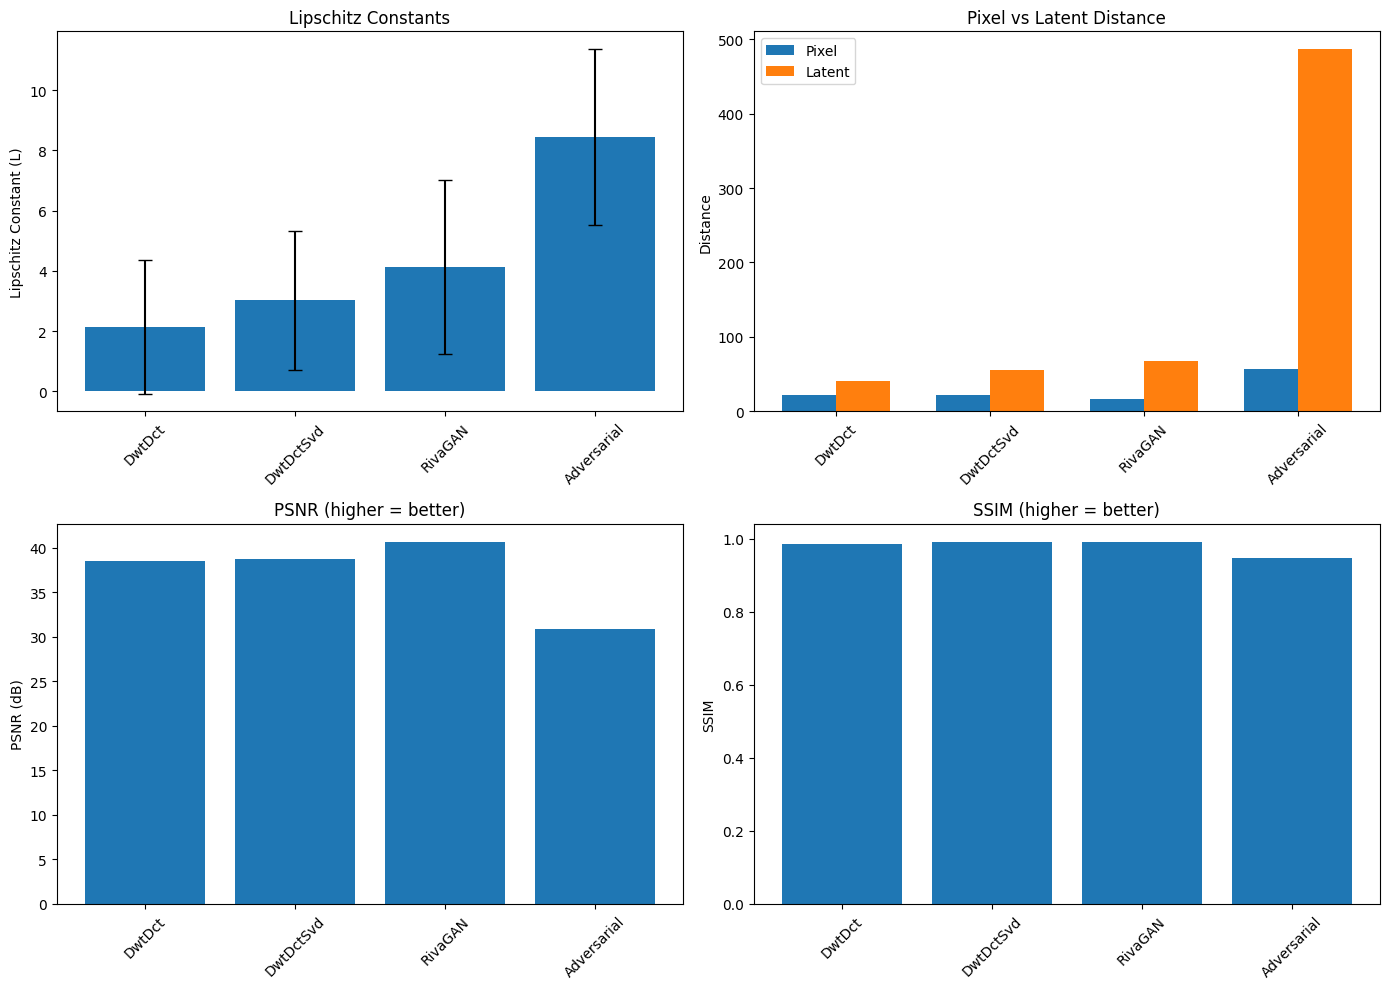

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods = list(baseline_results.keys()) + ['Adversarial']
L_means = [baseline_results[k]['L_mean'] for k in baseline_results.keys()] + [adversarial_results['L_mean']]
L_stds = [baseline_results[k]['L_std'] for k in baseline_results.keys()] + [adversarial_results['L_std']]

# Plot 1: Lipschitz (top-left)
axes[0,0].bar(methods, L_means, yerr=L_stds, capsize=5)
axes[0,0].set_ylabel('Lipschitz Constant (L)')
axes[0,0].set_title('Lipschitz Constants')
axes[0,0].tick_params(axis='x', rotation=45)

pixel_means = [baseline_results[k]['pixel_dist_mean'] for k in baseline_results.keys()] + [adversarial_results['pixel_dist_mean']]
latent_means = [baseline_results[k]['latent_dist_mean'] for k in baseline_results.keys()] + [adversarial_results['latent_dist_mean']]

x = np.arange(len(methods))
width = 0.35
# Plot 2: Distances (top-right)
axes[0,1].bar(x - width/2, pixel_means, width, label='Pixel')
axes[0,1].bar(x + width/2, latent_means, width, label='Latent')
axes[0,1].set_ylabel('Distance')
axes[0,1].set_title('Pixel vs Latent Distance')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(methods, rotation=45)
axes[0,1].legend()

# Plot 3: PSNR (bottom-left)
psnr_means = [baseline_results[k]['psnr_mean'] for k in baseline_results.keys()] + [adversarial_results['psnr_mean']]
axes[1,0].bar(methods, psnr_means)
axes[1,0].set_ylabel('PSNR (dB)')
axes[1,0].set_title('PSNR (higher = better)')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4: SSIM (bottom-right)
ssim_means = [baseline_results[k]['ssim_mean'] for k in baseline_results.keys()] + [adversarial_results['ssim_mean']]
axes[1,1].bar(methods, ssim_means)
axes[1,1].set_ylabel('SSIM')
axes[1,1].set_title('SSIM (higher = better)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'lipschitz_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## Save Results

In [26]:
import json

results_summary = {
    'baseline': baseline_results,
    'adversarial': adversarial_results,
    'attacked_image_quality': attacked_results,
    'detection_before_attack': {'det_rate': float(det_rate), 'avg_bit_acc': float(avg_bit_acc)},
    'detection_after_regen_vae': {'det_rate': float(attack_det_rate), 'avg_bit_acc': float(attack_avg_bit_acc)},
    'selected_hyperparams': {
        'epsilon_seed_mean_px': float(np.mean([c['eps_seed'] for c in selected_cfgs]) * 255),
        'epsilon_total_mean_px': float(np.mean([c['eps_total'] for c in selected_cfgs]) * 255),
        'lambda_wm_mean': float(np.mean([c['lambda_wm'] for c in selected_cfgs])),
        'technique': 'pairwise_ss_aggressive_highL',
    },
    'violation_ratio': ratio,
    'property_violated': bool(ratio > 3),
    'objective_primary_pre_attack_detectability': bool(det_rate > 0.9),
    'objective_attack_utility_degradation': bool((attacked_results['psnr_mean'] < 30) or (attacked_results['ssim_mean'] < 0.90)),
}
with open(os.path.join(output_dir, 'lipschitz_results.json'), 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f'\nResults saved to {output_dir}')



Results saved to /content/drive/MyDrive/lipschitz_results/run_20260308_203954


# Step 5: Gaussian Blur & JPEG Compression Robustness

## Helper functions

In [30]:
import os
import cv2
import numpy as np
import torch
from tqdm import tqdm
from pytorch_msssim import ssim, ms_ssim
import numpy as np
import torch

def eval_psnr_ssim_msssim_tensors(x_ref, x_test):
    """
    x_ref, x_test: torch tensors of shape [1, 3, H, W] in [-1, 1]
    returns: psnr, ssim, msssim
    """
    xr = ((x_ref.clamp(-1, 1) + 1.0) / 2.0).float()
    xt = ((x_test.clamp(-1, 1) + 1.0) / 2.0).float()

    # keep both on same device and same dtype
    xt = xt.to(device=xr.device, dtype=xr.dtype)

    mse = torch.mean((xr - xt) ** 2).item()
    psnr = -10.0 * np.log10(max(mse, 1e-12))

    ssim_val = ssim(
        xr, xt,
        data_range=1.0,
        size_average=True
    ).item()

    msssim_val = ms_ssim(
        xr, xt,
        data_range=1.0,
        size_average=True
    ).item()

    return psnr, ssim_val, msssim_val

## Gaussian Blur

In [42]:
print("\n=== EXPERIMENT 3: GAUSSIAN BLUR ROBUSTNESS ===")

import cv2
import os
import numpy as np
import torch
from tqdm import tqdm

blur_radii = [2, 4, 6, 8]

blur_detection_results = {r: [] for r in blur_radii}
blur_bitacc_results = {r: [] for r in blur_radii}
blur_psnr_vals = {r: [] for r in blur_radii}
blur_ssim_vals = {r: [] for r in blur_radii}
blur_msssim_vals = {r: [] for r in blur_radii}

per_image_blur_results = []

for i, img_path in enumerate(tqdm(image_paths)):
    img_name = os.path.basename(img_path)
    adv_path = os.path.join(adv_save_dir, img_name)

    if not os.path.exists(adv_path):
        continue

    x_clean = load_image_tensor(img_path, device).float()
    x_adv = load_image_tensor(adv_path, device)

    row = {
        "img_name": img_name,
        "L": float(lipschitz_constants_adv[i]) if i < len(lipschitz_constants_adv) else np.nan,
    }

    for r in blur_radii:
        x = x_adv.squeeze(0).permute(1, 2, 0).detach().float().cpu().numpy()
        x = (x + 1.0) / 2.0
        x = np.clip(x, 0, 1).astype(np.float32)

        k = 2 * r + 1
        x_blur = cv2.GaussianBlur(x, (k, k), sigmaX=float(r), sigmaY=float(r))

        x_blur = torch.tensor(x_blur, dtype=torch.float32, device=device)
        x_blur = x_blur.permute(2, 0, 1).unsqueeze(0)
        x_blur = x_blur * 2.0 - 1.0

        det, bit_acc, p_val, margin = detect_pair_watermark(
            x_blur.to(dtype=carriers0.dtype), carriers0, carriers1, wm_bits, threshold=20
        )

        psnr, ssim_val, msssim = eval_psnr_ssim_msssim_tensors(x_clean, x_blur)

        blur_detection_results[r].append(bool(det))
        blur_bitacc_results[r].append(float(bit_acc))
        blur_psnr_vals[r].append(float(psnr))
        blur_ssim_vals[r].append(float(ssim_val))
        blur_msssim_vals[r].append(float(msssim))

        row[f"blur_det_r{r}"] = float(det)
        row[f"blur_bitacc_r{r}"] = float(bit_acc)
        row[f"blur_psnr_r{r}"] = float(psnr)

    per_image_blur_results.append(row)


=== EXPERIMENT 3: GAUSSIAN BLUR ROBUSTNESS ===


100%|██████████| 20/20 [00:01<00:00, 10.70it/s]


In [43]:
print("\n=== GAUSSIAN BLUR RESULTS ===")

for r in blur_radii:
    det_rate = np.mean(blur_detection_results[r])
    bit_acc = np.mean(blur_bitacc_results[r])
    psnr_mean = np.mean(blur_psnr_vals[r])
    ssim_mean = np.mean(blur_ssim_vals[r])
    msssim_mean = np.mean(blur_msssim_vals[r])

    print(f"Blur radius {r}")
    print(f"  detection rate: {det_rate*100:.1f}%")
    print(f"  bit accuracy: {bit_acc:.3f}")
    print(f"  PSNR: {psnr_mean:.2f}")
    print(f"  SSIM: {ssim_mean:.4f}")
    print(f"  MSSSIM: {msssim_mean:.4f}")


=== GAUSSIAN BLUR RESULTS ===
Blur radius 2
  detection rate: 100.0%
  bit accuracy: 0.797
  PSNR: 20.67
  SSIM: 0.6036
  MSSSIM: 0.8622
Blur radius 4
  detection rate: 75.0%
  bit accuracy: 0.681
  PSNR: 18.17
  SSIM: 0.3782
  MSSSIM: 0.6951
Blur radius 6
  detection rate: 65.0%
  bit accuracy: 0.631
  PSNR: 17.16
  SSIM: 0.2957
  MSSSIM: 0.5872
Blur radius 8
  detection rate: 50.0%
  bit accuracy: 0.603
  PSNR: 16.57
  SSIM: 0.2577
  MSSSIM: 0.5152


## Gaussian Blur: Visualizations

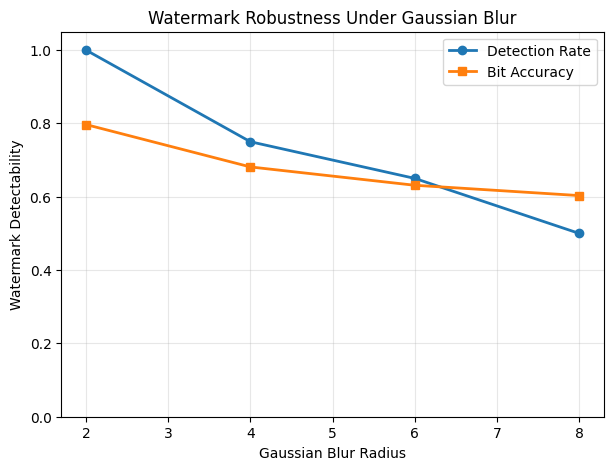

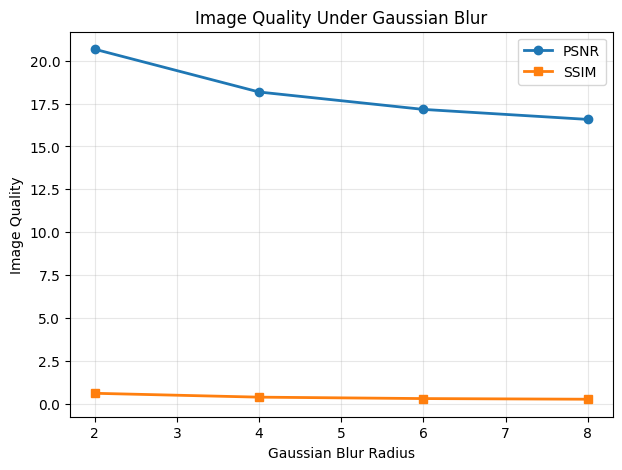

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Gradual degradation vs blur radius
blur_radii = [2, 4, 6, 8]
detection_rates = [
    np.mean(blur_detection_results[r]) for r in blur_radii
]

bit_accuracies = [
    np.mean(blur_bitacc_results[r]) for r in blur_radii
]

psnr_vals = [
    np.mean(blur_psnr_vals[r]) for r in blur_radii
]

ssim_vals = [
    np.mean(blur_ssim_vals[r]) for r in blur_radii
]

plt.figure(figsize=(7,5))

plt.plot(blur_radii, detection_rates, marker='o', linewidth=2, label='Detection Rate')
plt.plot(blur_radii, bit_accuracies, marker='s', linewidth=2, label='Bit Accuracy')

plt.xlabel("Gaussian Blur Radius")
plt.ylabel("Watermark Detectability")
plt.title("Watermark Robustness Under Gaussian Blur")
plt.ylim(0,1.05)

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

# image quality curve
plt.figure(figsize=(7,5))

plt.plot(blur_radii, psnr_vals, marker='o', linewidth=2, label='PSNR')
plt.plot(blur_radii, ssim_vals, marker='s', linewidth=2, label='SSIM')

plt.xlabel("Gaussian Blur Radius")
plt.ylabel("Image Quality")
plt.title("Image Quality Under Gaussian Blur")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

## JPEG Compression RObustness

In [50]:
print("\n=== EXPERIMENT 4: JPEG COMPRESSION ROBUSTNESS ===")

import os
import cv2
import numpy as np
import torch
from tqdm import tqdm

jpeg_qualities = [90, 70, 50, 30]

jpeg_detection_results = {q: [] for q in jpeg_qualities}
jpeg_bitacc_results = {q: [] for q in jpeg_qualities}

per_image_jpeg_results = []

for i, img_path in enumerate(tqdm(image_paths)):
    img_name = os.path.basename(img_path)
    adv_path = os.path.join(adv_save_dir, img_name)

    if not os.path.exists(adv_path):
        continue

    x_adv = load_image_tensor(adv_path, device)

    row = {
        "img_name": img_name,
        "L": float(lipschitz_constants_adv[i]) if i < len(lipschitz_constants_adv) else np.nan,
    }

    x = x_adv.squeeze(0).permute(1, 2, 0).detach().float().cpu().numpy()
    x = (x + 1) / 2
    x = np.clip(x, 0, 1).astype(np.float32)

    for q in jpeg_qualities:
        tmp_file = f"tmp_jpeg_{img_name}_q{q}.jpg"

        cv2.imwrite(
            tmp_file,
            (x * 255).astype(np.uint8)[:, :, ::-1],
            [int(cv2.IMWRITE_JPEG_QUALITY), q]
        )

        img_jpeg = cv2.imread(tmp_file, cv2.IMREAD_COLOR)
        img_jpeg = img_jpeg[:, :, ::-1].astype(np.float32) / 255.0

        img_jpeg = torch.tensor(img_jpeg, dtype=carriers0.dtype, device=device)
        img_jpeg = img_jpeg.permute(2, 0, 1).unsqueeze(0)
        img_jpeg = img_jpeg * 2 - 1

        det, bit_acc, p_val, margin = detect_pair_watermark(
            img_jpeg, carriers0, carriers1, wm_bits, threshold=20
        )

        jpeg_detection_results[q].append(bool(det))
        jpeg_bitacc_results[q].append(float(bit_acc))

        row[f"jpeg_det_q{q}"] = float(det)
        row[f"jpeg_bitacc_q{q}"] = float(bit_acc)
        os.remove(tmp_file)

    per_image_jpeg_results.append(row)


=== EXPERIMENT 4: JPEG COMPRESSION ROBUSTNESS ===


100%|██████████| 20/20 [00:01<00:00, 17.26it/s]


In [46]:
print("\n=== JPEG RESULTS ===")

for q in jpeg_qualities:
    det_rate = np.mean(jpeg_detection_results[q])
    bit_acc = np.mean(jpeg_bitacc_results[q])

    print(f"JPEG quality {q}")
    print(f"  detection rate: {det_rate*100:.1f}%")
    print(f"  bit accuracy: {bit_acc:.3f}")


=== JPEG RESULTS ===
JPEG quality 90
  detection rate: 100.0%
  bit accuracy: 0.877
JPEG quality 70
  detection rate: 100.0%
  bit accuracy: 0.858
JPEG quality 50
  detection rate: 100.0%
  bit accuracy: 0.830
JPEG quality 30
  detection rate: 100.0%
  bit accuracy: 0.820


## JPEG Visualization

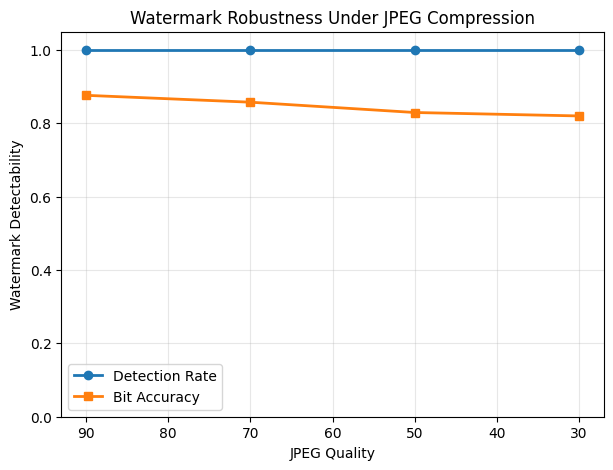

In [47]:
import matplotlib.pyplot as plt
import numpy as np

jpeg_qualities_sorted = sorted(jpeg_qualities, reverse=True)
jpeg_det_rates = [np.mean(jpeg_detection_results[q]) for q in jpeg_qualities_sorted]
jpeg_bit_accs = [np.mean(jpeg_bitacc_results[q]) for q in jpeg_qualities_sorted]

plt.figure(figsize=(7, 5))
plt.plot(jpeg_qualities_sorted, jpeg_det_rates, marker='o', linewidth=2, label='Detection Rate')
plt.plot(jpeg_qualities_sorted, jpeg_bit_accs, marker='s', linewidth=2, label='Bit Accuracy')

plt.xlabel("JPEG Quality")
plt.ylabel("Watermark Detectability")
plt.title("Watermark Robustness Under JPEG Compression")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.gca().invert_xaxis()  # stronger compression to the right
plt.show()

## latent amplification vs robustness

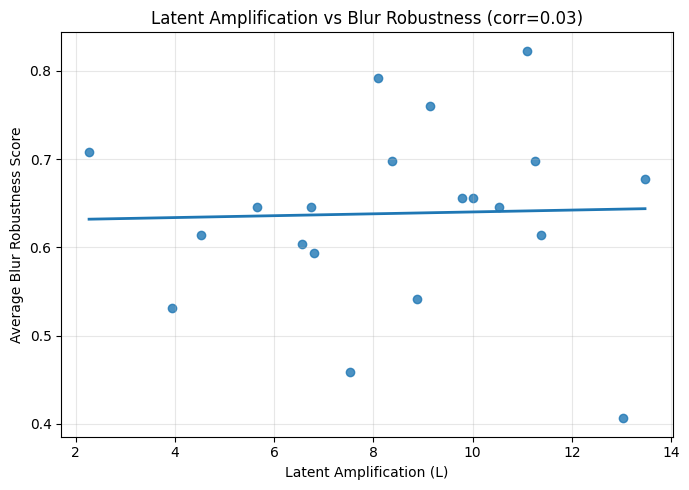

In [49]:
df_blur = pd.DataFrame(per_image_blur_results).copy()
df_blur["blur_robustness_score"] = (
    df_blur["blur_bitacc_r4"] +
    df_blur["blur_bitacc_r6"] +
    df_blur["blur_bitacc_r8"]
) / 3.0

plt.figure(figsize=(7, 5))
plt.scatter(df_blur["L"], df_blur["blur_robustness_score"], alpha=0.8)

z = np.polyfit(df_blur["L"], df_blur["blur_robustness_score"], 1)
p = np.poly1d(z)
xline = np.linspace(df_blur["L"].min(), df_blur["L"].max(), 100)
plt.plot(xline, p(xline), linewidth=2)

corr = np.corrcoef(df_blur["L"], df_blur["blur_robustness_score"])[0, 1]

plt.xlabel("Latent Amplification (L)")
plt.ylabel("Average Blur Robustness Score")
plt.title(f"Latent Amplification vs Blur Robustness (corr={corr:.2f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()